## Name: Samit Bhisikar

## Roll. No: A3 33
## ML Lab-6

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
df = pd.read_csv("seeds.csv")

In [9]:
df.head()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [10]:
X = df.drop("Class (1, 2, 3)", axis=1)
y_original = df["Class (1, 2, 3)"]

print("Input shape:", X.shape)
print("Target shape:", y_original.shape)

Input shape: (210, 7)
Target shape: (210,)


In [11]:
y = y_original - 1

print("Original Classes:")
print(sorted(y_original.unique()))

print("\nANN encoded classes:")
print(sorted(y.unique()))

Original Classes:
[np.int64(1), np.int64(2), np.int64(3)]

ANN encoded classes:
[np.int64(0), np.int64(1), np.int64(2)]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 168
Testing samples: 42


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [15]:
scaler.fit_transform(X_test)

array([[-0.13481356, -0.30885661,  1.63834475, -0.72108928,  0.28326462,
        -0.76430253, -1.20943602],
       [-0.86696115, -0.79265998, -1.079508  , -0.44412568, -1.01611436,
        -0.08296069, -0.1493714 ],
       [ 0.3031065 ,  0.49244271, -0.70339658,  0.66153059,  0.00779627,
        -0.80711315,  0.9685525 ],
       [-1.32882996, -1.4578896 , -0.42131302, -1.40250766, -1.05769449,
         0.74059948, -0.71763216],
       [ 1.23710786,  1.05184035,  1.89804073,  0.79121989,  1.36954545,
        -0.66416923,  1.14006393],
       [-0.46667485, -0.42224803, -0.31833013, -0.17155833, -0.40280748,
         2.38191499,  0.06140168],
       [ 2.15058173,  2.0799225 ,  0.78313902,  2.07492419,  1.98285233,
         0.67094153,  1.87157051],
       [ 0.37495276,  0.31101645,  1.0697001 ,  0.12079214,  0.53534414,
         1.33559449, -0.56678476],
       [ 1.65107916,  1.67171341,  0.42941519,  1.6418938 ,  1.48908831,
        -0.57346877,  1.60087175],
       [ 1.28842662,  1.2257

In [20]:
model = Sequential([
    Input(shape=(7,)),

    Dense(24, activation="relu"),

    Dense(12, activation="relu"),

    Dense(3, activation="softmax")
])

In [21]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 24)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531 (2.07 KB)

 Trainable params: 531 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [28]:
loss = "sparse_categorical_crossentropy"

In [29]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [30]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.0746 - loss: 1.2061 - val_accuracy: 0.2647 - val_loss: 1.1014
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2910 - loss: 1.1116 - val_accuracy: 0.5588 - val_loss: 1.0171
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 1.0288 - val_accuracy: 0.7647 - val_loss: 0.9380
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5970 - loss: 0.9538 - val_accuracy: 0.7647 - val_loss: 0.8635
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6493 - loss: 0.8849 - val_accuracy: 0.7941 - val_loss: 0.7941
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6791 - loss: 0.8202 - val_accuracy: 0.8235 - val_loss: 0.7303
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7612 - loss: 0.7606 - val_accuracy: 0.8235 - val_loss: 0.6723
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8060 - loss: 0.7056 - val_accuracy: 0.8529 - val_loss: 0.6213

In [32]:
print("Training completed.")
print("Number of epochs actually completed:", len(history.history["loss"]))

Training completed.
Number of epochs actually completed: 100


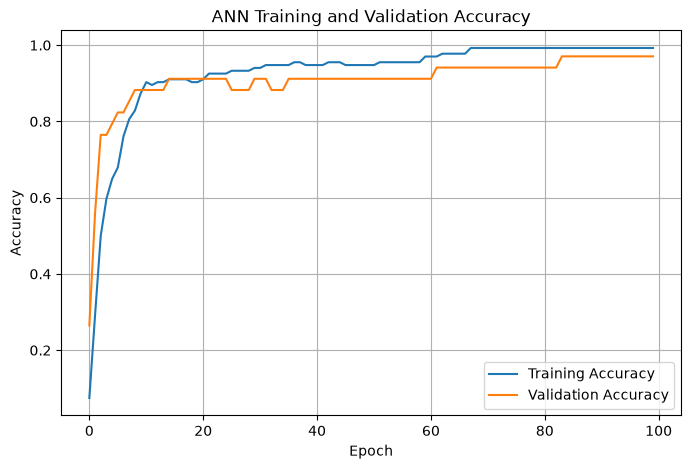

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

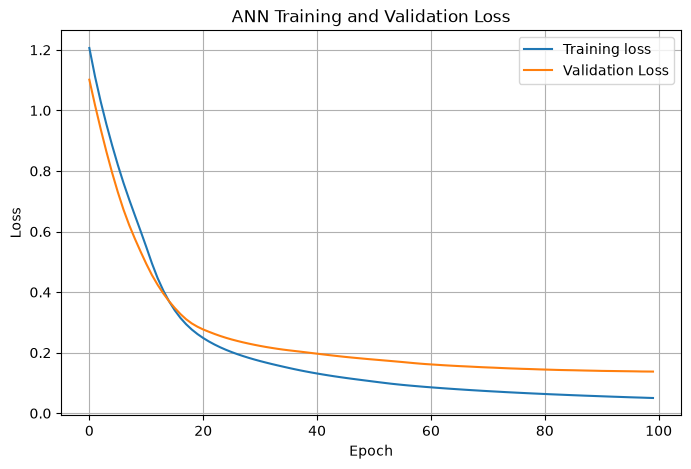

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [36]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8333 - loss: 0.5498
Test Loss: 0.5497502088546753
Test Accuracy: 0.8333333134651184


In [37]:
y_prob = model.predict(X_test_scaled, verbose=1)

print(y_prob[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[[9.9838543e-01 2.3888542e-04 1.3757024e-03]
 [3.8176004e-02 1.0486413e-03 9.6077532e-01]
 [9.2988932e-01 5.5559952e-02 1.4550661e-02]
 [1.1255881e-04 7.0467031e-06 9.9988043e-01]
 [7.4373864e-05 9.9988067e-01 4.4959030e-05]]


In [38]:
y_pred = np.argmax(y_prob, axis=1)

print("Predicted encoded classes:")
print(y_pred[:10])

Predicted encoded classes:
[0 2 0 2 1 2 1 1 1 1]


In [39]:
y_pred_original = y_pred+1
y_test_original = y_test+1

print("Predicted classes:")
print(y_pred_original[:10])

Predicted classes:
[1 3 1 3 2 3 2 2 2 2]


In [40]:
comparison = pd.DataFrame({"Actual Class": y_test_original.values, "Predicted Class": y_pred_original})

comparison.head()

,Actual Class,Predicted Class
0,1,1
1,3,3
2,2,1
3,3,3
4,2,2


In [41]:
accuracy = accuracy_score(y_test_original, y_pred_original)
print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


In [42]:
precision = precision_score(y_test_original, y_pred_original, average="weighted")
print("Precision:", precision)

Precision: 0.8416394335511983


In [44]:
recall = recall_score(y_test_original, y_pred_original, average="weighted")
print("Recall: ", recall)

Recall:  0.8333333333333334


In [45]:
f1 = f1_score(y_test_original, y_pred_original, average="weighted")
print("F1 Score:", f1)

F1 Score: 0.8218482156771078


In [49]:
metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [accuracy, precision, recall, f1]
})
metrics.head()

,Metric,Score
0,Accuracy,0.833333
1,Precision,0.841639
2,Recall,0.833333
3,F1 Score,0.821848


In [51]:
print(classification_report(y_test_original, y_pred_original))

              precision    recall  f1-score   support

           1       0.89      0.57      0.70        14
           2       0.81      0.93      0.87        14
           3       0.82      1.00      0.90        14

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.82        42
weighted avg       0.84      0.83      0.82        42



In [52]:
cm = confusion_matrix(y_test_original, y_pred_original)
print(cm)

[[ 8  3  3]
 [ 1 13  0]
 [ 0  0 14]]


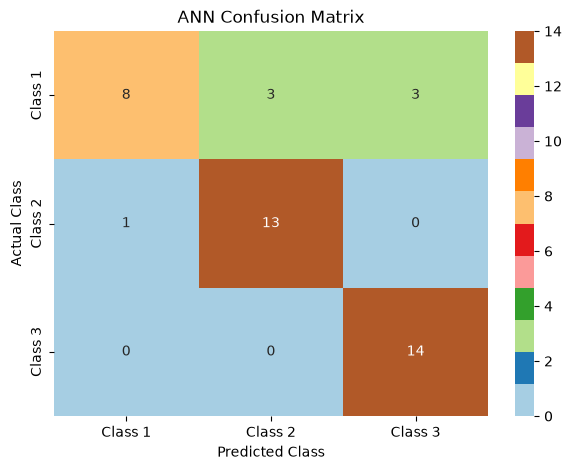

In [54]:
plt.figure(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Paired", xticklabels=["Class 1", "Class 2", "Class 3"],
           yticklabels=["Class 1", "Class 2", "Class 3"])

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()